In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cooler
import bioframe
import cooltools
from cooltools.lib import plotting
import cooler as clr
import h5py
import coolbox
from coolbox.api import *
from coolbox.utilities import GenomeRange
from pygenometracks import readBed, readGtf
from pygenometracks.tracks import BedTrack

import glob
from pathlib import Path


%cd /home/varshini/uc_analyses/
import utils, coolbox_helpers
%cd /home/varshini/LoopCall_Analysis_Scripts
import re

warnings.filterwarnings("ignore")

import logging
logging.getLogger('matplotlib.font_manager').disabled = True
from matplotlib.backends.backend_pdf import PdfPages

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

plt.rcParams.update({
    "text.usetex": False})
plt.rc('pdf',fonttype = 42)

In [3]:
def make_region_plot_mod(region, resolution, microc_file,
                     bw_list, condition_order, gene_annot_name, bedgraph_fname=None, plot_variants=False,
                     file_bottom=None, cmap_chip='tab10', bigwig_bins=1600, autoscale=True, plot_bed=False,
                        variant_track_height=2, custom_valranges=None, plot_genes=True, 
                         highlight_region_list=[], highlight_buffer=1000):
    
    """
    Function that makes a plot of a region with Micro-C, ChIP-seq, and Pro-seq.
    
    region: (str) string that specifies region for plotting.
    resolution: (int) resolution of micro-c map used
    highlight_region_list: List of regions of format [chr, start, end] to highlight
    microc_file: (str) file path to micro-c data
    microc_title: (str) title for micro-c
    chip_list_list: List of lists containing paths to bigwigs
    forward_proseq_list: List of paths to forward strand pro-seq files
    reverse_proseq_list: List of paths to reverse strand pro-seq files
    condition_order: List indicating order of conditions to plot. 
    """
    print(region, resolution, microc_file)
    heatmap = Cool(microc_file, file_bottom=file_bottom, resolution=resolution, **MICROC_PLOTTING_PARAMS) 
    frame = heatmap + Spacer(SPACER_HEIGHT*3)
    if plot_bed:
        frame+=NewBed(*BED_PARAMS) + TrackHeight(1.5) + Spacer(SPACER_HEIGHT)
    #frame +=  BED(finemapped_variant_name, border_only=True, 
    #              alpha=0.1, show_score='yes', linewidth=0.5, display="collapsed", height=1, edgecolor="#0099BB") + Spacer(SPACER_HEIGHT)
    if len(bw_list)>0:
        bigwig_list = coolbox_helpers.make_bigwig_list(bw_list, region, condition_order, autoscale=False)
        cmap_arr = sns.color_palette(cmap_chip, n_colors=len(bigwig_list))

        for i, bigwig in enumerate(bigwig_list):
            if autoscale:
                frame += coolbox_helpers.auto_scale_bigwig(bigwig, region) + Color(cmap_arr[i]) + Spacer(SPACER_HEIGHT)
            else:
                frame += bigwig + MaxValue(custom_valranges[i]) + MinValue(0) + Color(cmap_arr[i]) + Spacer(SPACER_HEIGHT)

    if bedgraph_fname is not None:
        frame += BigWig(bedgraph_fname) + Title("HbF_Base") + Color("#EE7733") + MaxValue(30) + MinValue(0)+ Spacer(SPACER_HEIGHT)
    
    if plot_variants:
        frame+=SNP(finemapped_variant_name, **VARIANTS_PARAMS) \
        + HLines(0, line_width=2, line_style='-',color='k') + Title("HbF GWAS [-log10(p)]")  + TrackHeight(variant_track_height) + Spacer(SPACER_HEIGHT)
    
    if plot_genes:
        annotations = NewBed(*GTF_PARAMS)
#     annotations = GTF(gene_annot_name, color=["#000000"], gene_rows=1, 
#                       filter_named_genes=True, row_filter=None) 
    if len(highlight_region_list) > 0:
        highlight_regions = []
        for highlight_region in highlight_region_list:
            highlight_region[1] -= highlight_buffer
            highlight_region[2] += highlight_buffer 
            highlight_regions.append(tuple(highlight_region))

        highlights = HighLights(highlight_regions, **HIGHLIGHT_PARAMS)
        with highlights:
            frame+=annotations
    else:
        frame+=annotations
    return frame


def multiplot(mcool1, mcool2, peaks, resolution=5000):
    for index, row in peaks.iterrows():
        plt.figure()
        region_str = get_locus_from_coord(row, flank=200_000)

        # Reverse these
        microc_file1 = mcool1
        microc_file2 = mcool2
        microc_title = f"{region_str} at {resolution}"
        heatmap = Cool(microc_file1, file_bottom=microc_file2,
                       resolution=resolution, **MICROC_PLOTTING_PARAMS) + Title(microc_title)
        frame = heatmap
        annotations = NewBed(*ANNOTATIONS_PARAMS)
        frame += annotations
        frame += XAxis()
        fig = frame.plot(region_str)



In [4]:
class ChromName(Track):
    """
    Track for show chromosome name.

    Parameters
    ----------
    fontsize : float
        Font name to show.

    offset : float
        Offset ratio to the start position.
    """

    DEFAULT_PROPERTIES = {
        "fontsize": 50,
        "offset": 0.45,
    }

    def __init__(self, **kwargs):
        properties = ChromName.DEFAULT_PROPERTIES.copy()
        properties.update(kwargs)
        super().__init__(properties)

    def fetch_data(self, gr: GenomeRange, **kwargs):
        return gr.chrom  # return chromosome name

    def plot(self, ax, gr: GenomeRange, **kwargs):
        x = gr.start + self.properties['offset'] * (gr.end - gr.start)
        ax.text(x, 0, gr.chrom, fontsize=self.properties['fontsize'])
        ax.set_xlim(gr.start, gr.end)


class NewBed(Track):
    """
    Custom pygenometracks class that allows for control over the aesthetics of gene annotations in
    region plots.
    """

    def __init__(self, coolbox_prop_dict, pygenometracks_prop_dict):
        super().__init__(coolbox_prop_dict)  # init
        self.pygenometracks_object = BedTrack(pygenometracks_prop_dict)

    def fetch_data(self, gr, **kwargs):
        pass

    def plot(self, ax, gr, **kwargs):
        #         x = gr.start + self.properties['offset'] * (gr.end - gr.start)
        #         ax.text(x, 0, gr.chrom, fontsize=self.properties['fontsize'])
        #         ax.set_xlim(gr.start, gr.end)
        self.pygenometracks_object.plot(ax, gr.chrom, gr.start, gr.end)
        ax.set_xlim([gr.start, gr.end])

In [5]:
# define the bigwig and RNAseq files 
base_dir = '/mnt/coldstorage/Varshmallow/'

def get_chip_list(base_dir='/mnt/coldstorage/Varshmallow/', phase=1, phase2=None, 
                  include=['RNASeq', 'ATAC', 'H3K27ac', 'H3K4me1']):

    chip_dict = {}
    chip_dict[f'RNASeq_P{phase}'] = f'{base_dir}Blood_RNAseq/Phase{phase}_RNA_chr.bw'
    
    # ATAC-Seq
    chip_dict[f'ATAC_P{phase}'] = f'{base_dir}Blood_ATAC/Phase{phase}_ATAC.bw'
    
    chip_dict['NIPBL'] = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/bigwigs/GSM8864683_HUDEP-2_NIPBL_rep1_2_mean.bw'
 
    # GATA-1 
    
    
    if phase2 is not None:
        chip_dict[f'ATAC_P{phase2}'] = f'{base_dir}Blood_ATAC/Phase{phase2}_ATAC.bw'
        chip_dict[f'RNASeq_P{phase2}'] = f'{base_dir}Blood_RNAseq/Phase{phase2}_RNA_chr.bw'
        
    # Histone ChIP
    chip_dir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/bigwigs/'

    directory = os.fsencode(chip_dir)
    
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        rm = re.match(rf'\w*P{phase}_CTCF\S*', filename)
        if rm is not None:
            chip_dict[f'CTCF_P{phase}'] = f'{chip_dir}{rm.group(0)}'

        rm = re.match(rf'\w*P{phase}_H3K27ac\S*', filename)
        if rm is not None:
            chip_dict[f'H3K27ac_P{phase}']  = f'{chip_dir}{rm.group(0)}'

        rm = re.match(rf'\w*P{phase}_H3K4me1\S*', filename)
        if rm is not None:
            chip_dict[f'H3K4me1_P{phase}'] = f'{chip_dir}{rm.group(0)}'
       
        rm = re.match(r'\w*GATA1\S*', filename)
        if rm is not None:
            chip_dict[f'GATA1'] = f'{base_dir}Blood_ChIP/P{phase}/{rm.group(0)}'
            
        
    if phase2 is not None:
        for file in os.listdir(directory):
            filename = os.fsdecode(file)
            rm = re.match(rf'\w*P{phase2}_CTCF\S*', filename)
            if rm is not None:
                chip_dict[f'CTCF_P{phase2}'] = f'{chip_dir}{rm.group(0)}'

            rm = re.match(rf'\w*P{phase2}_H3K27ac\S*', filename)
            if rm is not None:
                chip_dict[f'H3K27ac_P{phase2}']  = f'{chip_dir}{rm.group(0)}'

            rm = re.match(rf'\w*P{phase2}_H3K4me1\S*', filename)
            if rm is not None:
                chip_dict[f'H3K4me1_P{phase2}'] = f'{chip_dir}{rm.group(0)}'

        
    chip_list = [chip_dict[key] for key in include]
    return chip_list


In [9]:
resolution = 2000
phases_microc = {1: 'Phase1_', 2:'Phase2_dedup',3:'Phase3_dedup'}

phases = ['Phase1_', 'Phase2_dedup', 'Phase3_dedup']
uc_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
uc_filenames = [os.path.join(uc_path, f"Sankaran_{p}merged.250.mcool") for p in phases]

savedir = os.path.join('/mnt/md0/varshini/Analysis/Blood/figs_v3/indiv_examples')
if not os.path.exists(savedir):
    os.mkdir(savedir)

In [7]:
GTF_FILENAME = "/mnt/md0/varshini/Gene_Annotations/hg38_genes_unique.bed"
GRNA = '/mnt/md0/varshini/Analysis/Blood/Tracks_Intersection_Analysis_NewCTCF/hbf_grna.bw'
finemapped_variant_name = '/mnt/md0/varshini/Analysis/Blood/hbf_gwas/METALOUT_inv1.bed'

# Define plotting aesthetics as global variables
HIGHLIGHT_PARAMS = {"color":"gray",
                   "alpha":1,
                   "border_line":True}

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-1.75,
                          "min_value":-4.5,}

VARIANTS_PARAMS = {
    "col_chrom":0, 
    "col_pos":2,
    "col_pval":6, 
    "threshold":10e-8, 
    "min_value":0, 
    "size":20,
    "alpha":0.75}

SPACER_HEIGHT = 0.4


## Matchmakers

In [9]:
def get_highlight(row):
    
    coord_round = int(np.round(row.coord))
    return [row.chr, coord_round-2000, coord_round+2000]
    
mm="/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed"
top_match = pd.read_csv(mm, sep='\t').sort_values(by='triangle_score_P3', ascending=False)

top_match_c4 = top_match[top_match['quant']==3]
top_match_c3 = top_match[top_match['quant']==2]
top_match_loci_c4 = [utils.get_locus_from_coord(row, 200_000) for _, row in top_match_c4.iterrows()]
top_match_loci_c3 = [utils.get_locus_from_coord(row, 200_000) for _, row in top_match_c3.iterrows()]

top_match_coords = top_match.apply(get_highlight, axis=1).tolist()

In [10]:
top_match_loci = top_match_loci_c4 + top_match_loci_c3

In [11]:
regions_mm = {
        'match_2d_1':'chr12:54105812-54505812',
        'match_2d_2':'chr17:44081815-44481815',
        'match_3a':'chr2:85303772-85703772',
        'match_4a': 'chr14:64648114-65048114'
}

In [12]:
tf_acrs_name = '/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/erythroid_tf_acrs_unique.bed'
ctcf_stranded_bed = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/merged_CTCF_P123_strand.bed'
resolution=2000

BED_PARAMS = [{"height":1},
                      {"file": ctcf_stranded_bed,
                      "max_labels":1,
                       "gene_rows":1,
                      "border_only":"true"}]

incl= ['H3K27ac_P2','H3K4me1_P2', 'CTCF_P2', 'RNASeq_P3']


MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                         "max_value":-1.25,
                          "min_value":-4.00,
                         "fontsize":6}


GTF_PARAMS = [
     {"height":4},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    #"gene_rows":1,
    "merge_transcripts":True,       
    "border_only":"true",
     "color":"#000000"
    }] 


In [13]:
tad_sampled

NameError: name 'tad_sampled' is not defined

In [14]:
os.listdir('/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers')

['tads_all.bed',
 'tads_position_sampled.bed',
 'nfe2_tf_only_100kb_merge10.0kb_clus_OLD.bed',
 'nfe2_only_tf_100kb_merge10.0kb_clus.bed',
 'erythroid_tf_acrs_all_enhancernotpromoternotctcf_200kb_merge10.0kb_clus.bed',
 'match_quantiles',
 'genomic_features',
 'arc',
 'tad_sampled.bed',
 'WT_enh_noCTCF_100kb_merge10.0kb_clus.bed',
 'aboreden_100kb_merge10.0kb_clus.bed',
 'nipbl_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed',
 'nfe2_tf_only_200kb_merge10.0kb_clus.bed',
 'nfe2_only_tf_clus.bed',
 'metaplots',
 'tothova_100kb_merge10.0kb_clus.bed',
 'tads_all_100kbw.bed',
 'erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed',
 'enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed',
 'tads_position_sampled_10kb_100kbw_clean.bed',
 'tf_acrs_sorted_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed',
 'matchmaker_scores_verify',
 'WT_enh_noCTCF_200kb_merge10.0kb_clus.bed',
 'tads_position_sampled_10kb_100kbw.bed',
 'matchmaker_scores',
 'tads.bed',
 'nipb

In [8]:
tad_sampled = pd.read_csv('/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/tads_position_sampled_10kb_100kbw.bed',
                          sep="\t", index_col=0)
tad_sampled['coord'] = tad_sampled['genomic_position']
tad_sampled = tad_sampled.sample(25, random_state=27)

tad_sampled['chr'] = tad_sampled['chr1']
tad_loci = [utils.get_locus_from_coord(row, 200_000) for _, row in tad_sampled.iterrows()]


In [41]:
resolution=2000
figs=[]
incl= ['H3K27ac_P2','H3K4me1_P2', 'CTCF_P2', 'RNASeq_P3']

for i, region_str in enumerate(tad_loci[:1]):

    chip_list = get_chip_list(include=incl, phase=2, phase2=3)
    frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                             chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                            bedgraph_fname=None, plot_variants=False, plot_bed=True,
                             file_bottom =  uc_filenames[2], cmap_chip="deep", autoscale=True, plot_genes=True)
    fig = frame.plot(region_str)
    figs.append(fig)
    fig.savefig(os.path.join(savedir, f"tads_ranked_{i}.svg"))


chr1:8679956-9079956 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28307/28307 [00:01<00:00, 27779.56it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5.68,-0.08


In [42]:
frame

frame.properties["width"] = 5
frame.properties["fontsize"] = 5

fig = frame.plot(region_str)
fig

In [24]:
top_match_loci[308]

'chr8:60126149-60526149'

In [13]:
ind_select = [4, 5, 11, 15, 22, 
              26, 41, 43, 45, 47,
              50, 52, 55, 71, 77, 
              92, 105, 121, 122, 131, 
              134, 139, 140, 144, 265,
             ]

ind_select = [8, 11, 15, 22, 26, 27, 30, 34, 46, 51, 64, 155, 261, 73, 93, 214, 334]

ind_select_2 = [33, 55, 63, 95, 96, 139, 141, 87]
ind_select_2 = [i + 359 for i in ind_select_2]
ind_select.extend(ind_select_2)

In [25]:
inds_extra=[309, 2, 3, 5]

In [18]:
ind_select_2

NameError: name 'ind_select_2' is not defined

In [19]:
top_match_loci[73]

'chr1:203111979-203511979'

In [20]:
savedir

'/mnt/md0/varshini/Analysis/Blood/figs_v3/indiv_examples'

In [26]:
resolution=2000
figs=[]

for match_id in inds_extra:
    print(match_id)
    print(top_match_coords[match_id])
    region_str = top_match_loci[match_id]
    chip_list = get_chip_list(include=incl, phase=2, phase2=3)
    frame = make_region_plot_mod(region_str, resolution, uc_filenames[0],
                             chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                            bedgraph_fname=None, plot_variants=False, plot_bed=True,
                             file_bottom =  uc_filenames[2], cmap_chip="deep", autoscale=True, plot_genes=True,
                                highlight_region_list=[top_match_coords[match_id]], highlight_buffer=20000)
    fig = frame.plot(region_str)
    figs.append(fig)
    fig.savefig(os.path.join(savedir, f"matchmaker_100kb_ranked_{match_id}.svg"))

309
['chr3', 20012829, 20016829]
chr12:108500267-108900267 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|██████████████████████████████████| 28307/28307 [00:00<00:00, 32439.64it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5.68,-0.08


2
['chr4', 153465172, 153549172]
chr4:153307172-153707172 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


...

DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 7.9799999999999995,-0.08


5
['chr3', 196085558, 196169558]
chr3:195927558-196327558 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool


100%|██████████████████████████████████| 28307/28307 [00:00<00:00, 32821.57it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 7.9799999999999995,-0.08


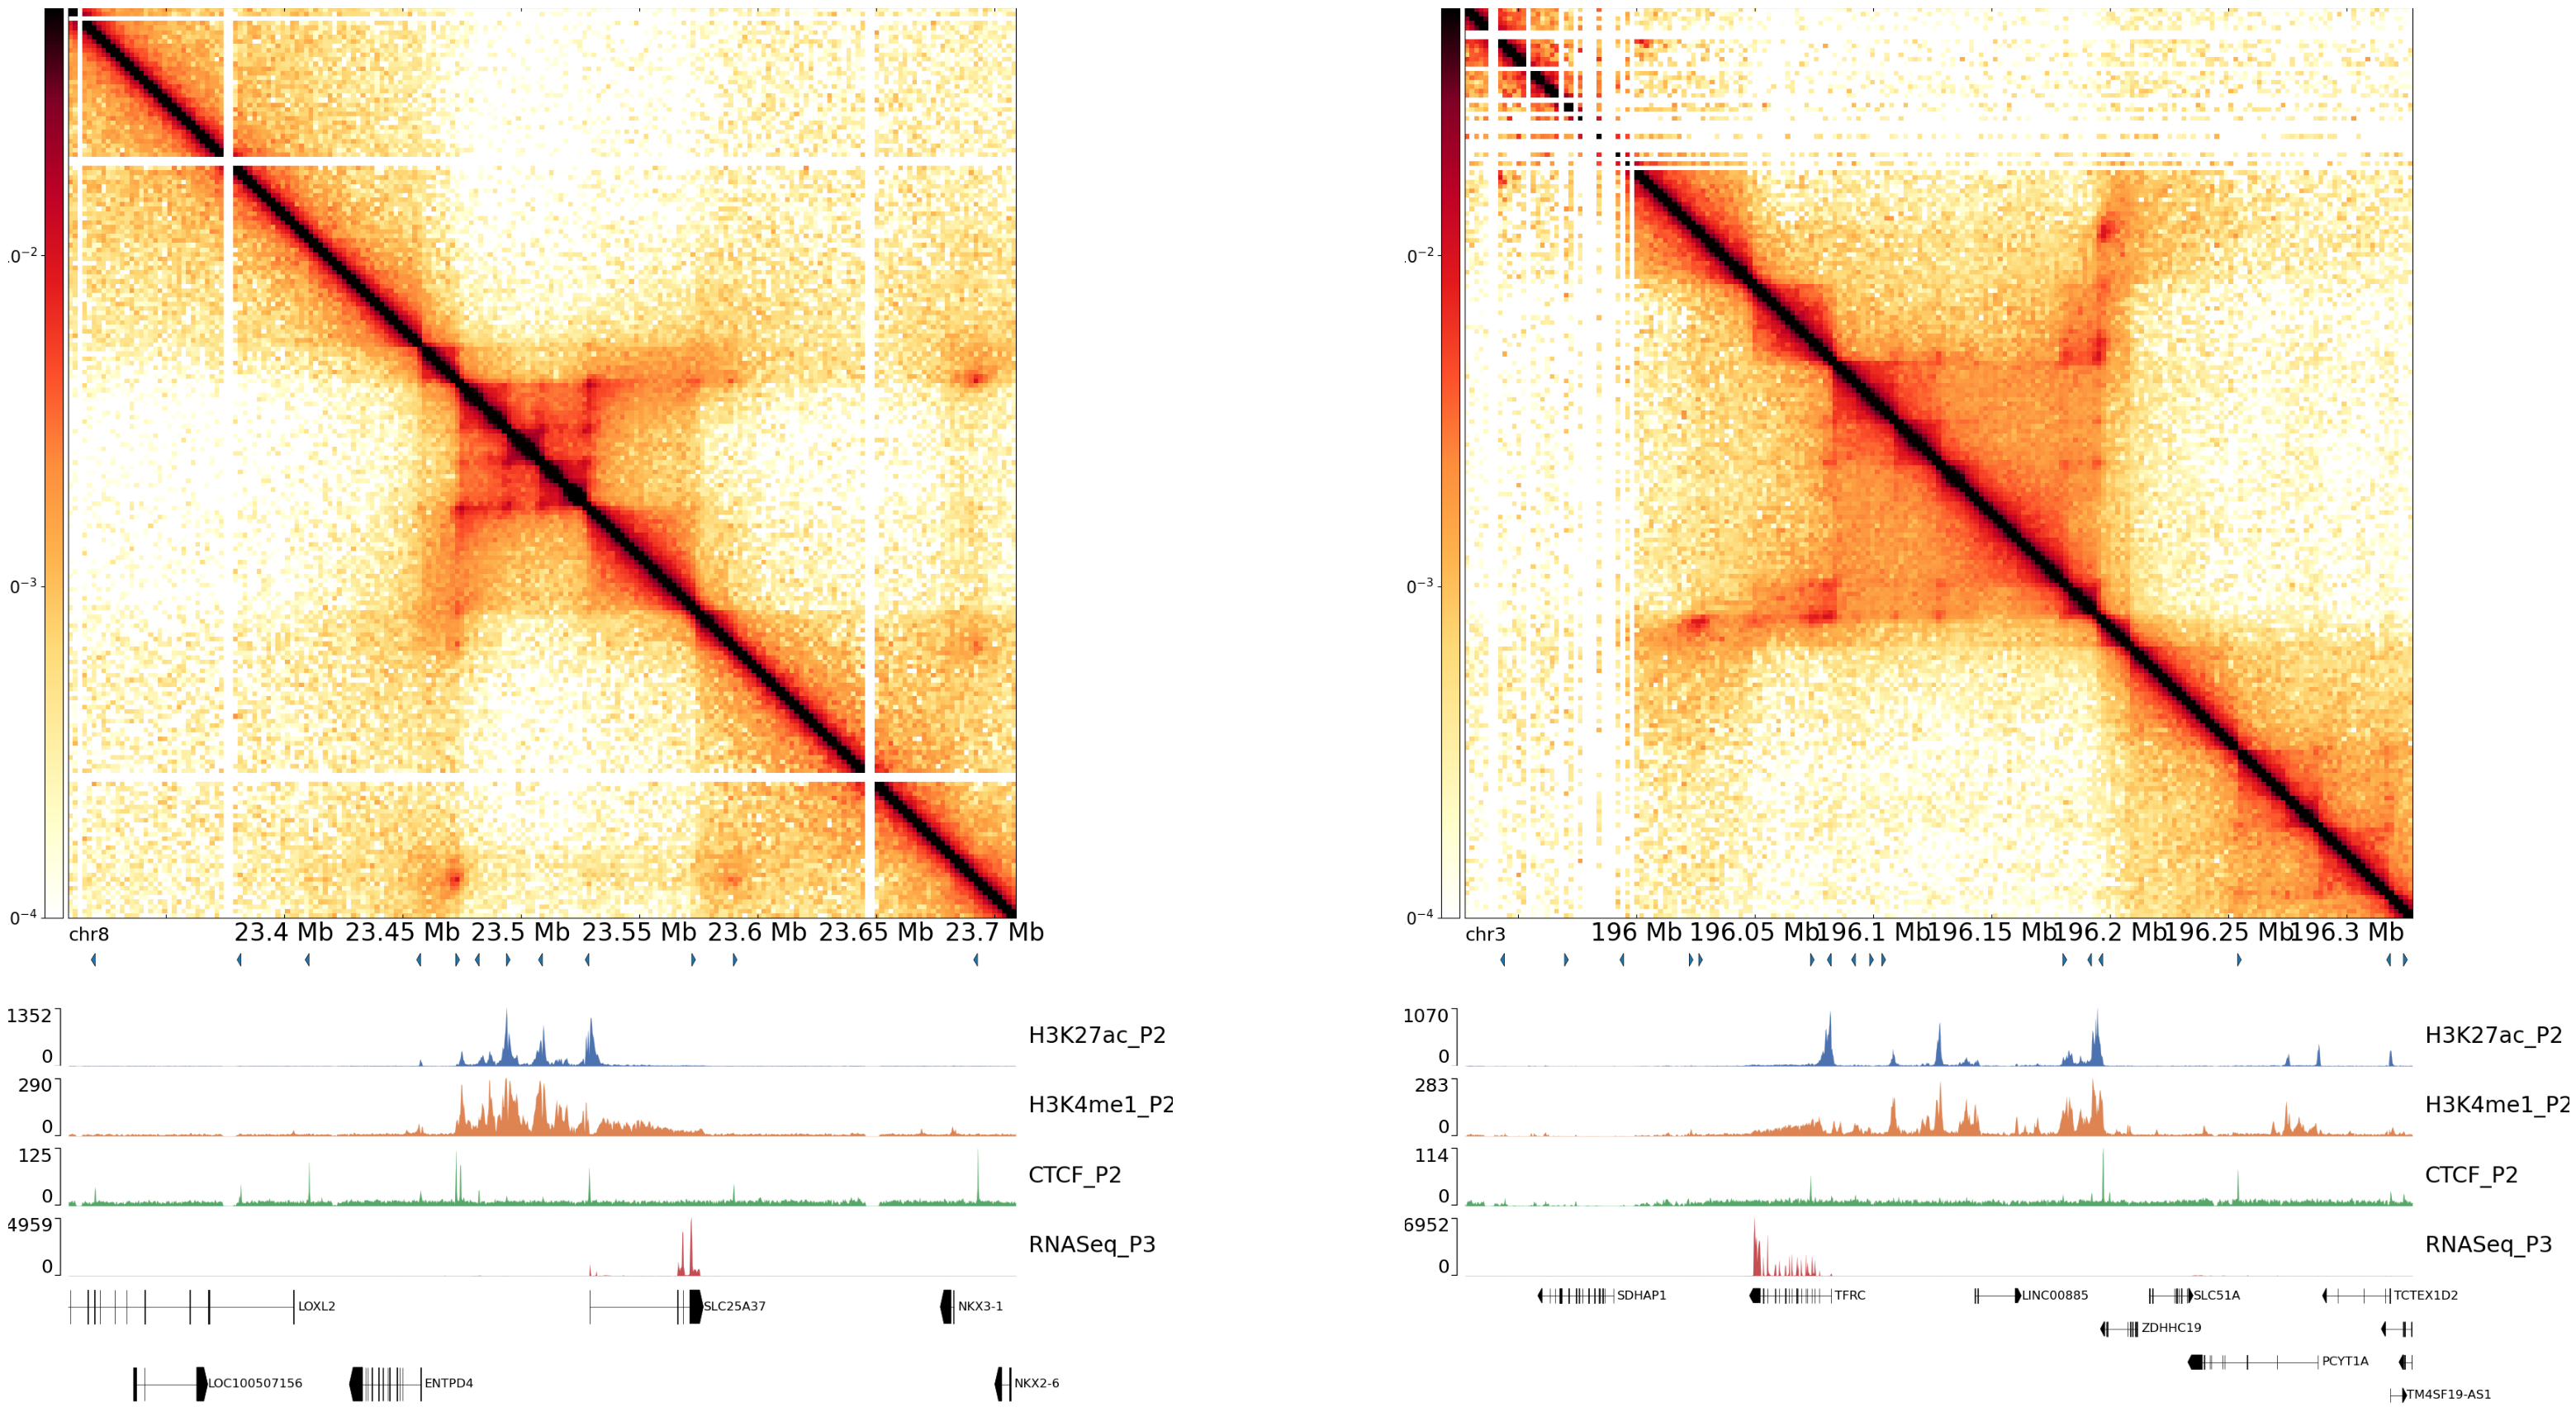

In [221]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
import numpy as np

def fig_to_array(fig):
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    return np.asarray(canvas.buffer_rgba())

fig1 = figs[0]
fig2 = figs[1]

fig, axs = plt.subplots(1, 2, figsize=(40,40))
axs[0].imshow(fig_to_array(fig1))
axs[0].axis("off")

axs[1].imshow(fig_to_array(fig2))
axs[1].axis("off")

plt.show()

In [182]:
len(figs)

25

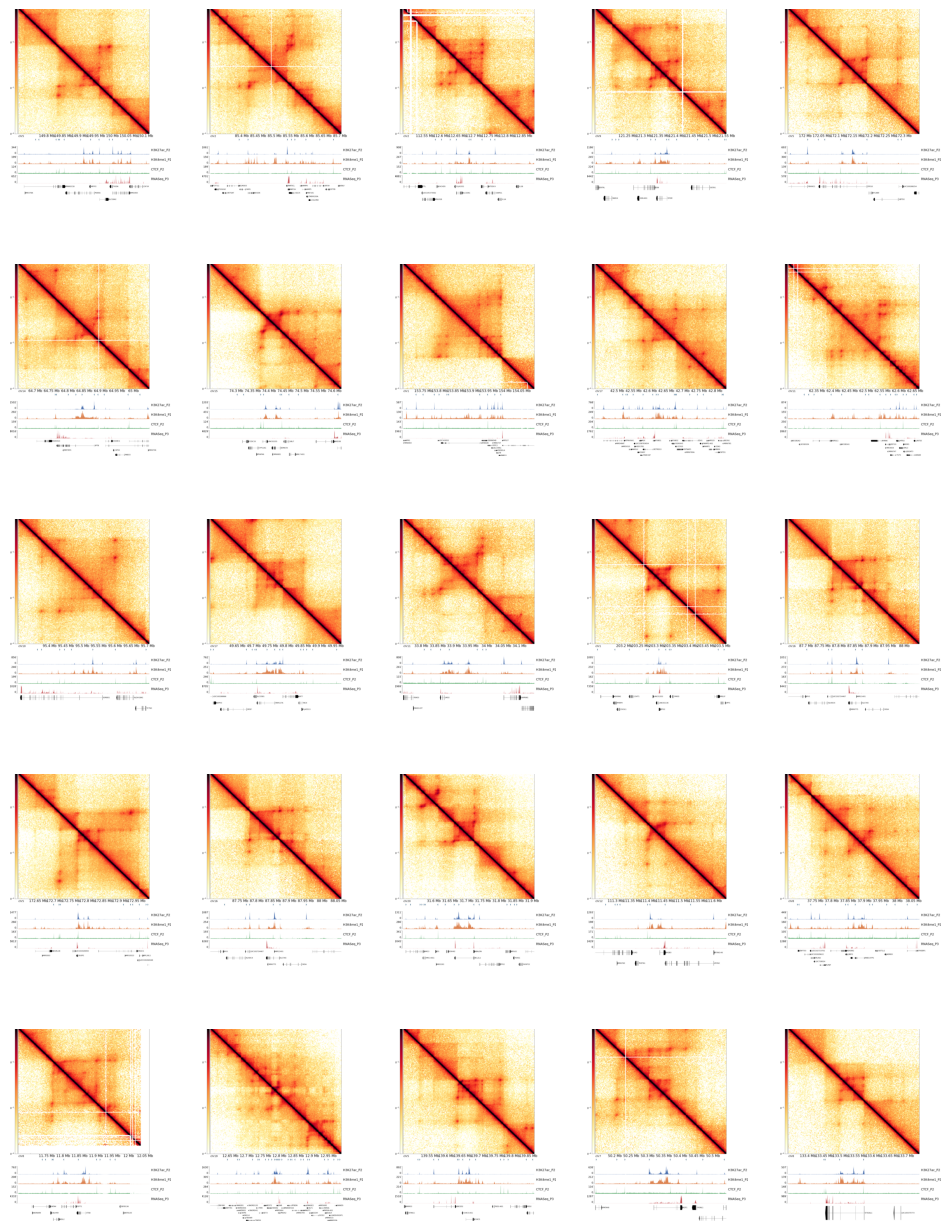

In [21]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
import numpy as np

def fig_to_array(fig):
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    return np.asarray(canvas.buffer_rgba())

# figure out division
fig, axs = plt.subplots(5, 5, figsize=(12,16))

for i in range(25):
    r, c = divmod(i, 5)
    curr_fig = figs[i]
    axs[r, c].imshow(fig_to_array(curr_fig))
    axs[r, c].axis("off")

plt.savefig("/mnt/md0/varshini/Analysis/Blood/figs_v2/matchmaker_examples_p13.svg", dpi=1200)
plt.show()

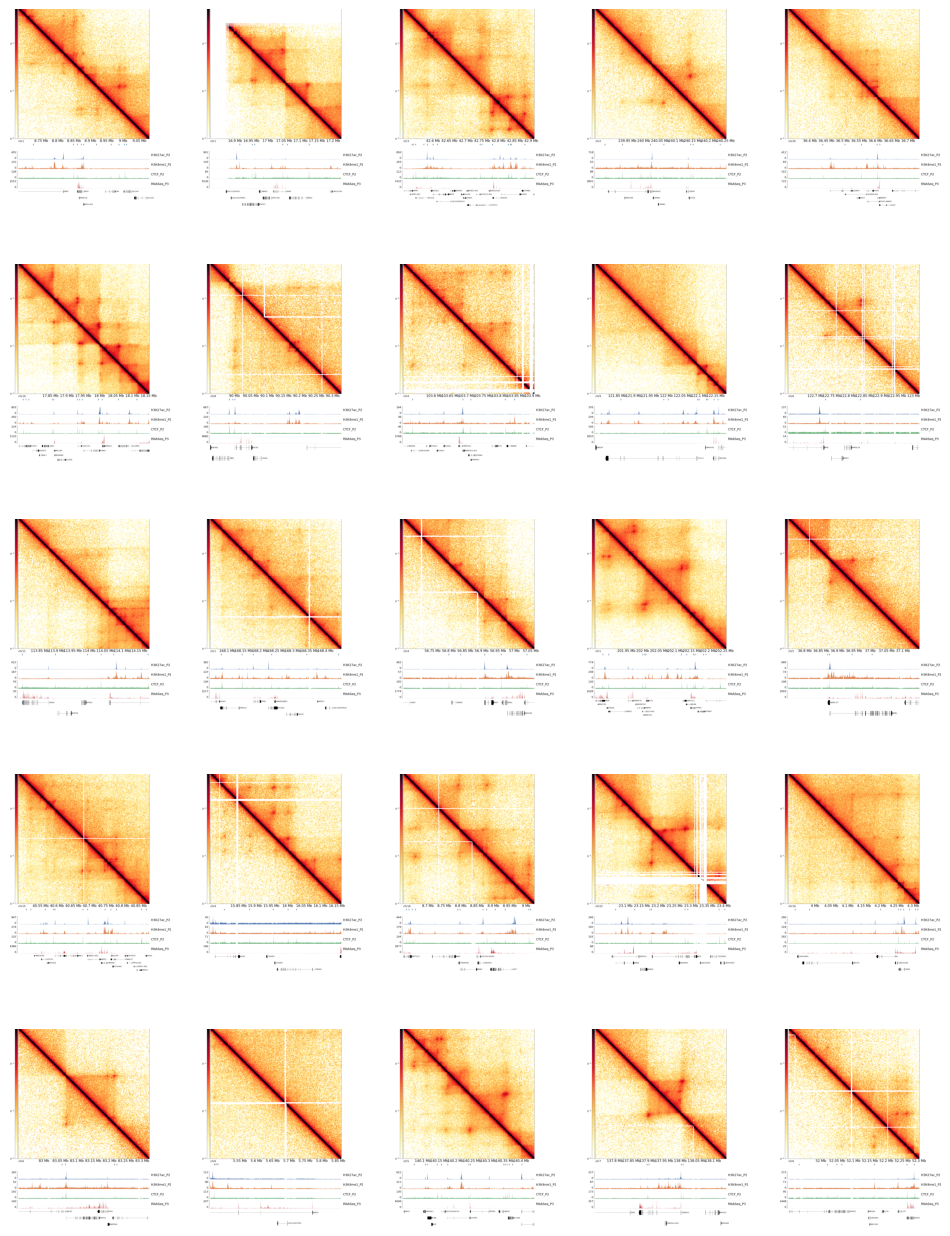

In [21]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
import numpy as np

def fig_to_array(fig):
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    return np.asarray(canvas.buffer_rgba())

# figure out division
fig, axs = plt.subplots(5, 5, figsize=(12,16))

for i in range(25):
    r, c = divmod(i, 5)
    curr_fig = figs[i]
    axs[r, c].imshow(fig_to_array(curr_fig))
    axs[r, c].axis("off")
plt.savefig("/mnt/md0/varshini/Analysis/Blood/figs_v2/random_tad_examples_distanceMatched.svg", dpi=1200)

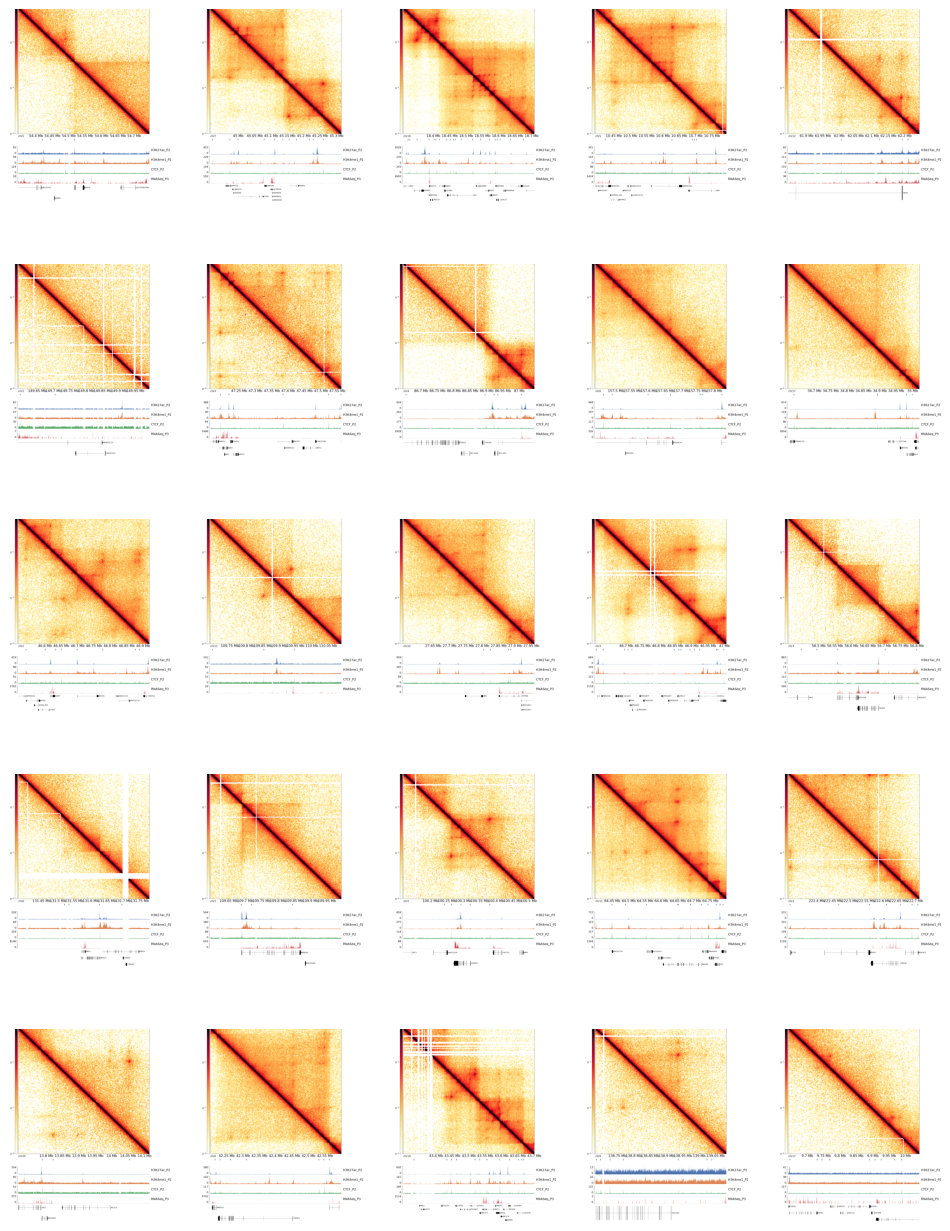

In [21]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
import numpy as np

def fig_to_array(fig):
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    return np.asarray(canvas.buffer_rgba())

# figure out division
fig, axs = plt.subplots(5, 5, figsize=(12,16))

for i in range(25):
    r, c = divmod(i, 5)
    curr_fig = figs[i]
    axs[r, c].imshow(fig_to_array(curr_fig))
    axs[r, c].axis("off")
plt.show()
    #plt.savefig("/mnt/md0/varshini/Analysis/Blood/figs_v2/random_tad_examples_allTads.svg", dpi=1200)

In [67]:
fig.savefig("test_fig.svg", dpi=600)

## Fountains

In [7]:
fountain_regions = ["chr15:74224095-74624095",
                   "chr16:70214962-70614962",
                    "chr11:37,878,224-39,141,769"]

In [21]:
resolution=2000
figsf=[]
MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                         "max_value":0.01,
                          "min_value":0.00,
                         "fontsize":18}

for reg in fountain_regions[:1]:
    region_str = reg
    chip_list = get_chip_list(include=incl, phase=2, phase2=3)
    frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                             chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                            bedgraph_fname=None, plot_variants=False, plot_bed=True,
                             file_bottom =  uc_filenames[2], cmap_chip="deep", autoscale=True, plot_genes=True, highlight_buffer=20000)
    fig = frame.plot(region_str)
    figsf.append(fig)
    #fig.savefig(os.path.join(savedir, f"matchmaker_100kb_ranked_{match_id}.svg"))

chr15:74224095-74624095 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 28307/28307 [00:01<00:00, 23666.82it/s]
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5.68,-0.08


In [313]:
top_match_loci[278]

'chr4:81586361-81986361'

chr4:79586361-83986361 10000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 28307/28307 [00:00<00:00, 33797.60it/s]


You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


[-6 -4 -1]


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 21.78,-0.08


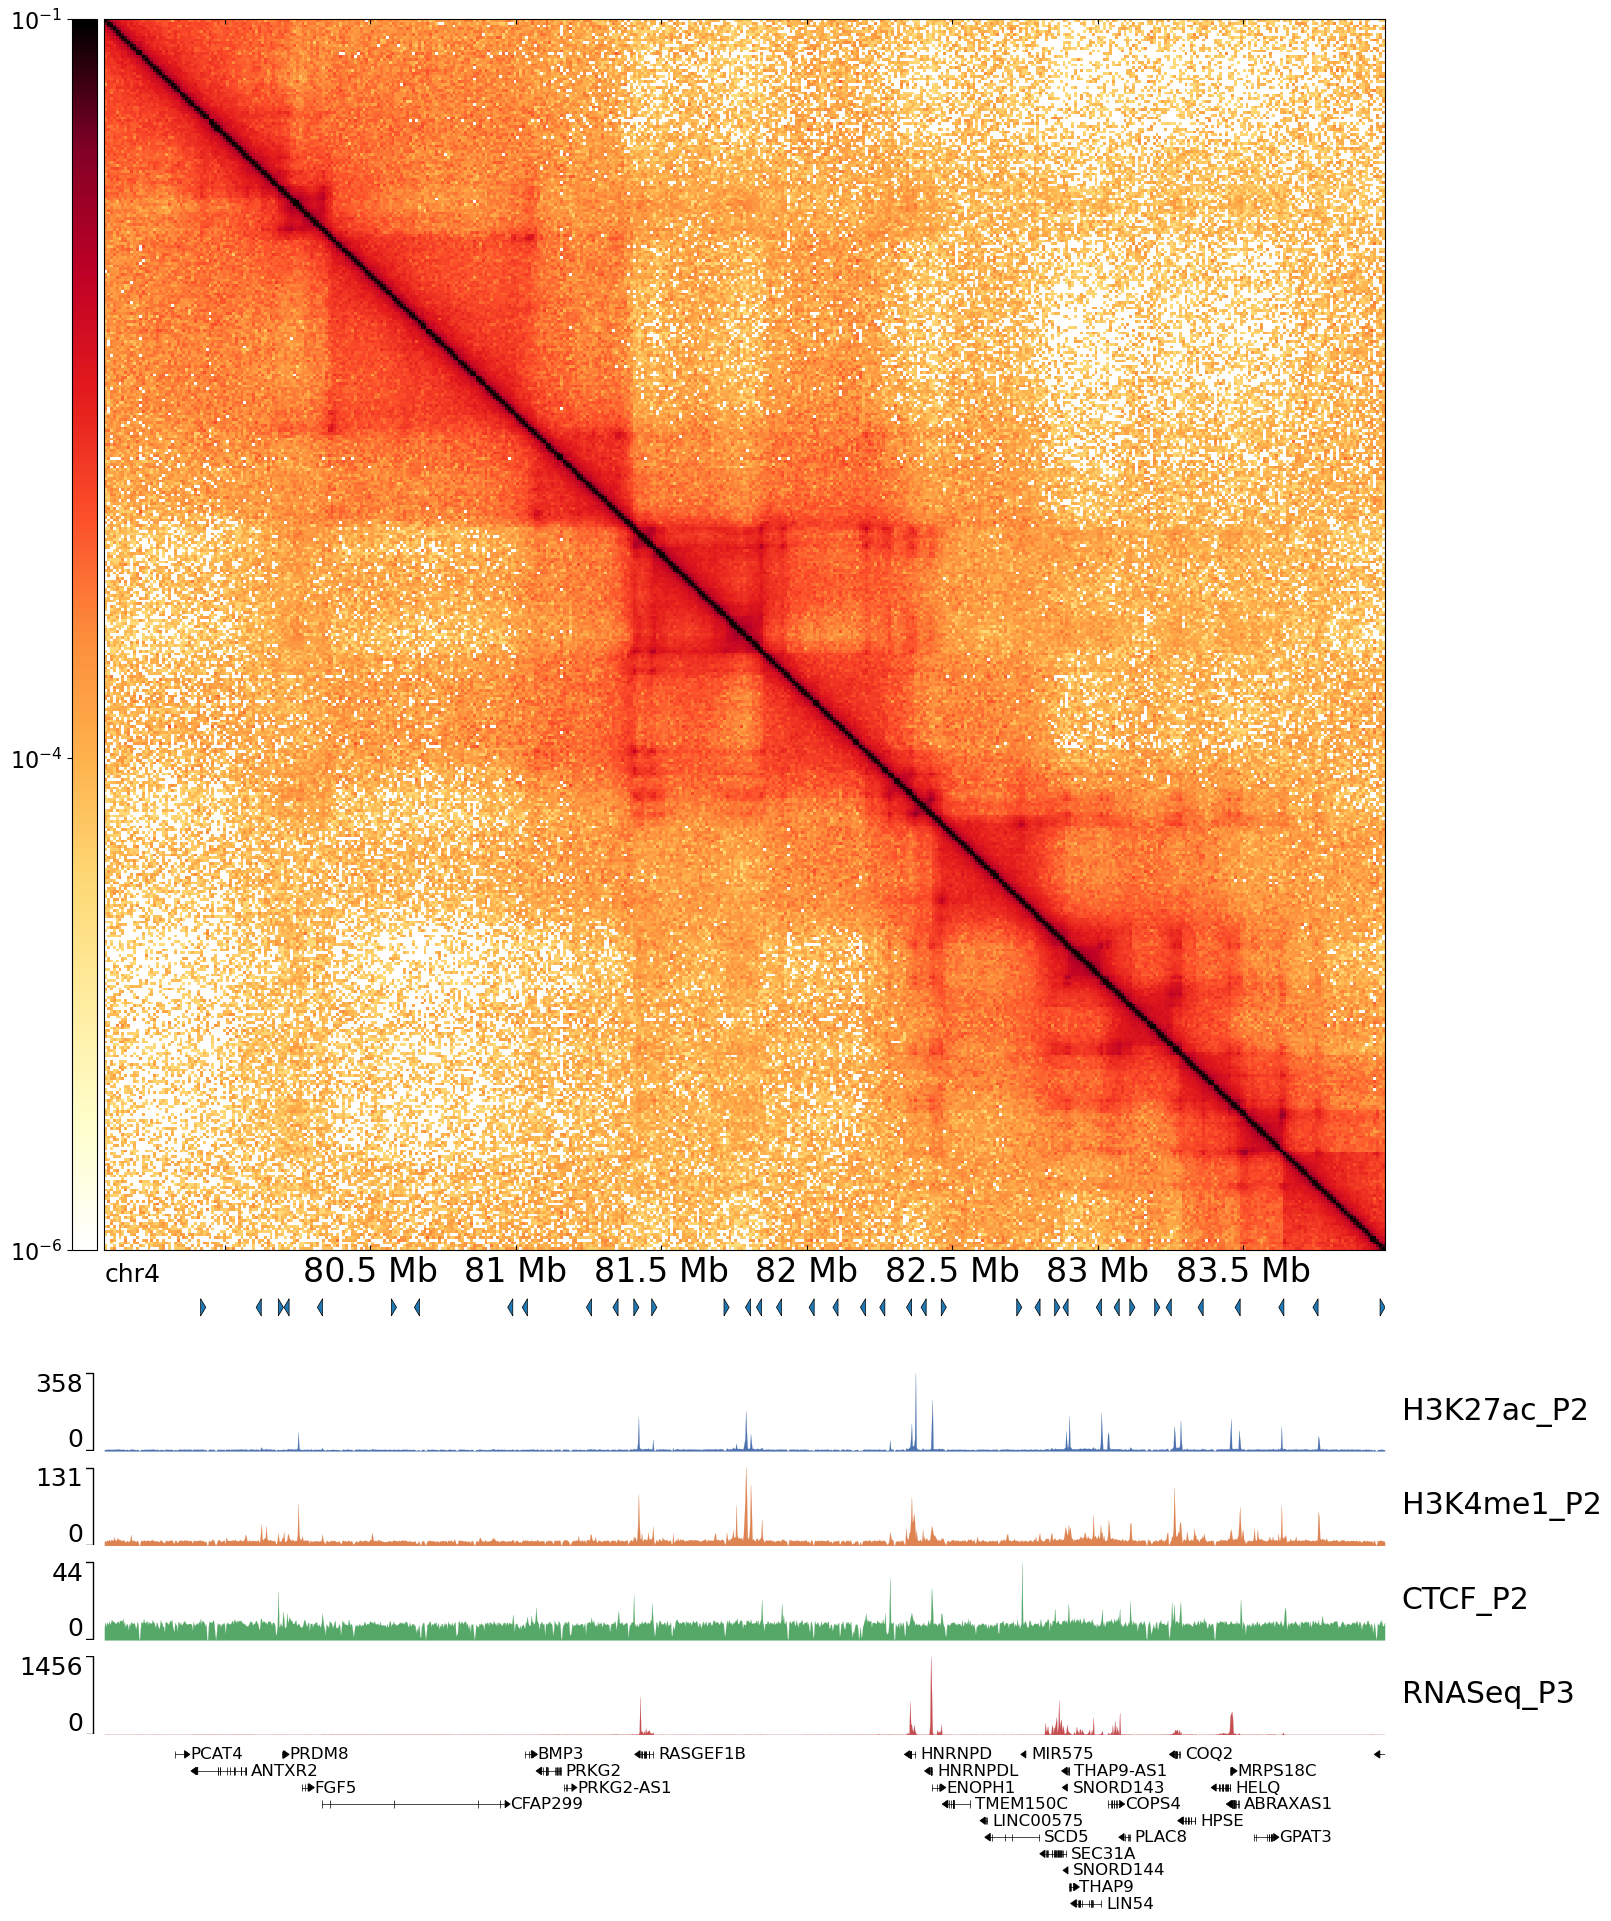

In [316]:
resolution=10000
figsf=[]

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                         "max_value":-1,
                          "min_value":-6,
                         "fontsize":18}


region_str = 'chr12:52105812-56505812'
region_str = 'chr17:42081815-46481815'
region_str = 'chr9:119164253-123564253'

chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                             chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                            bedgraph_fname=None, plot_variants=False, plot_bed=True,
                             file_bottom =  uc_filenames[2], cmap_chip="deep", autoscale=True, plot_genes=True,
                                highlight_region_list=[top_match_coords[match_id]], highlight_buffer=20000)
fig = frame.plot(region_str)
fig
    #fig.savefig(os.path.join(savedir, f"matchmaker_100kb_ranked_{match_id}.svg"))

In [289]:
top_match_loci.index('chr1:32560195-32960195')

200

chr16:70214962-70614962 3200 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 28307/28307 [00:00<00:00, 33509.15it/s]
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 7.9799999999999995,-0.08


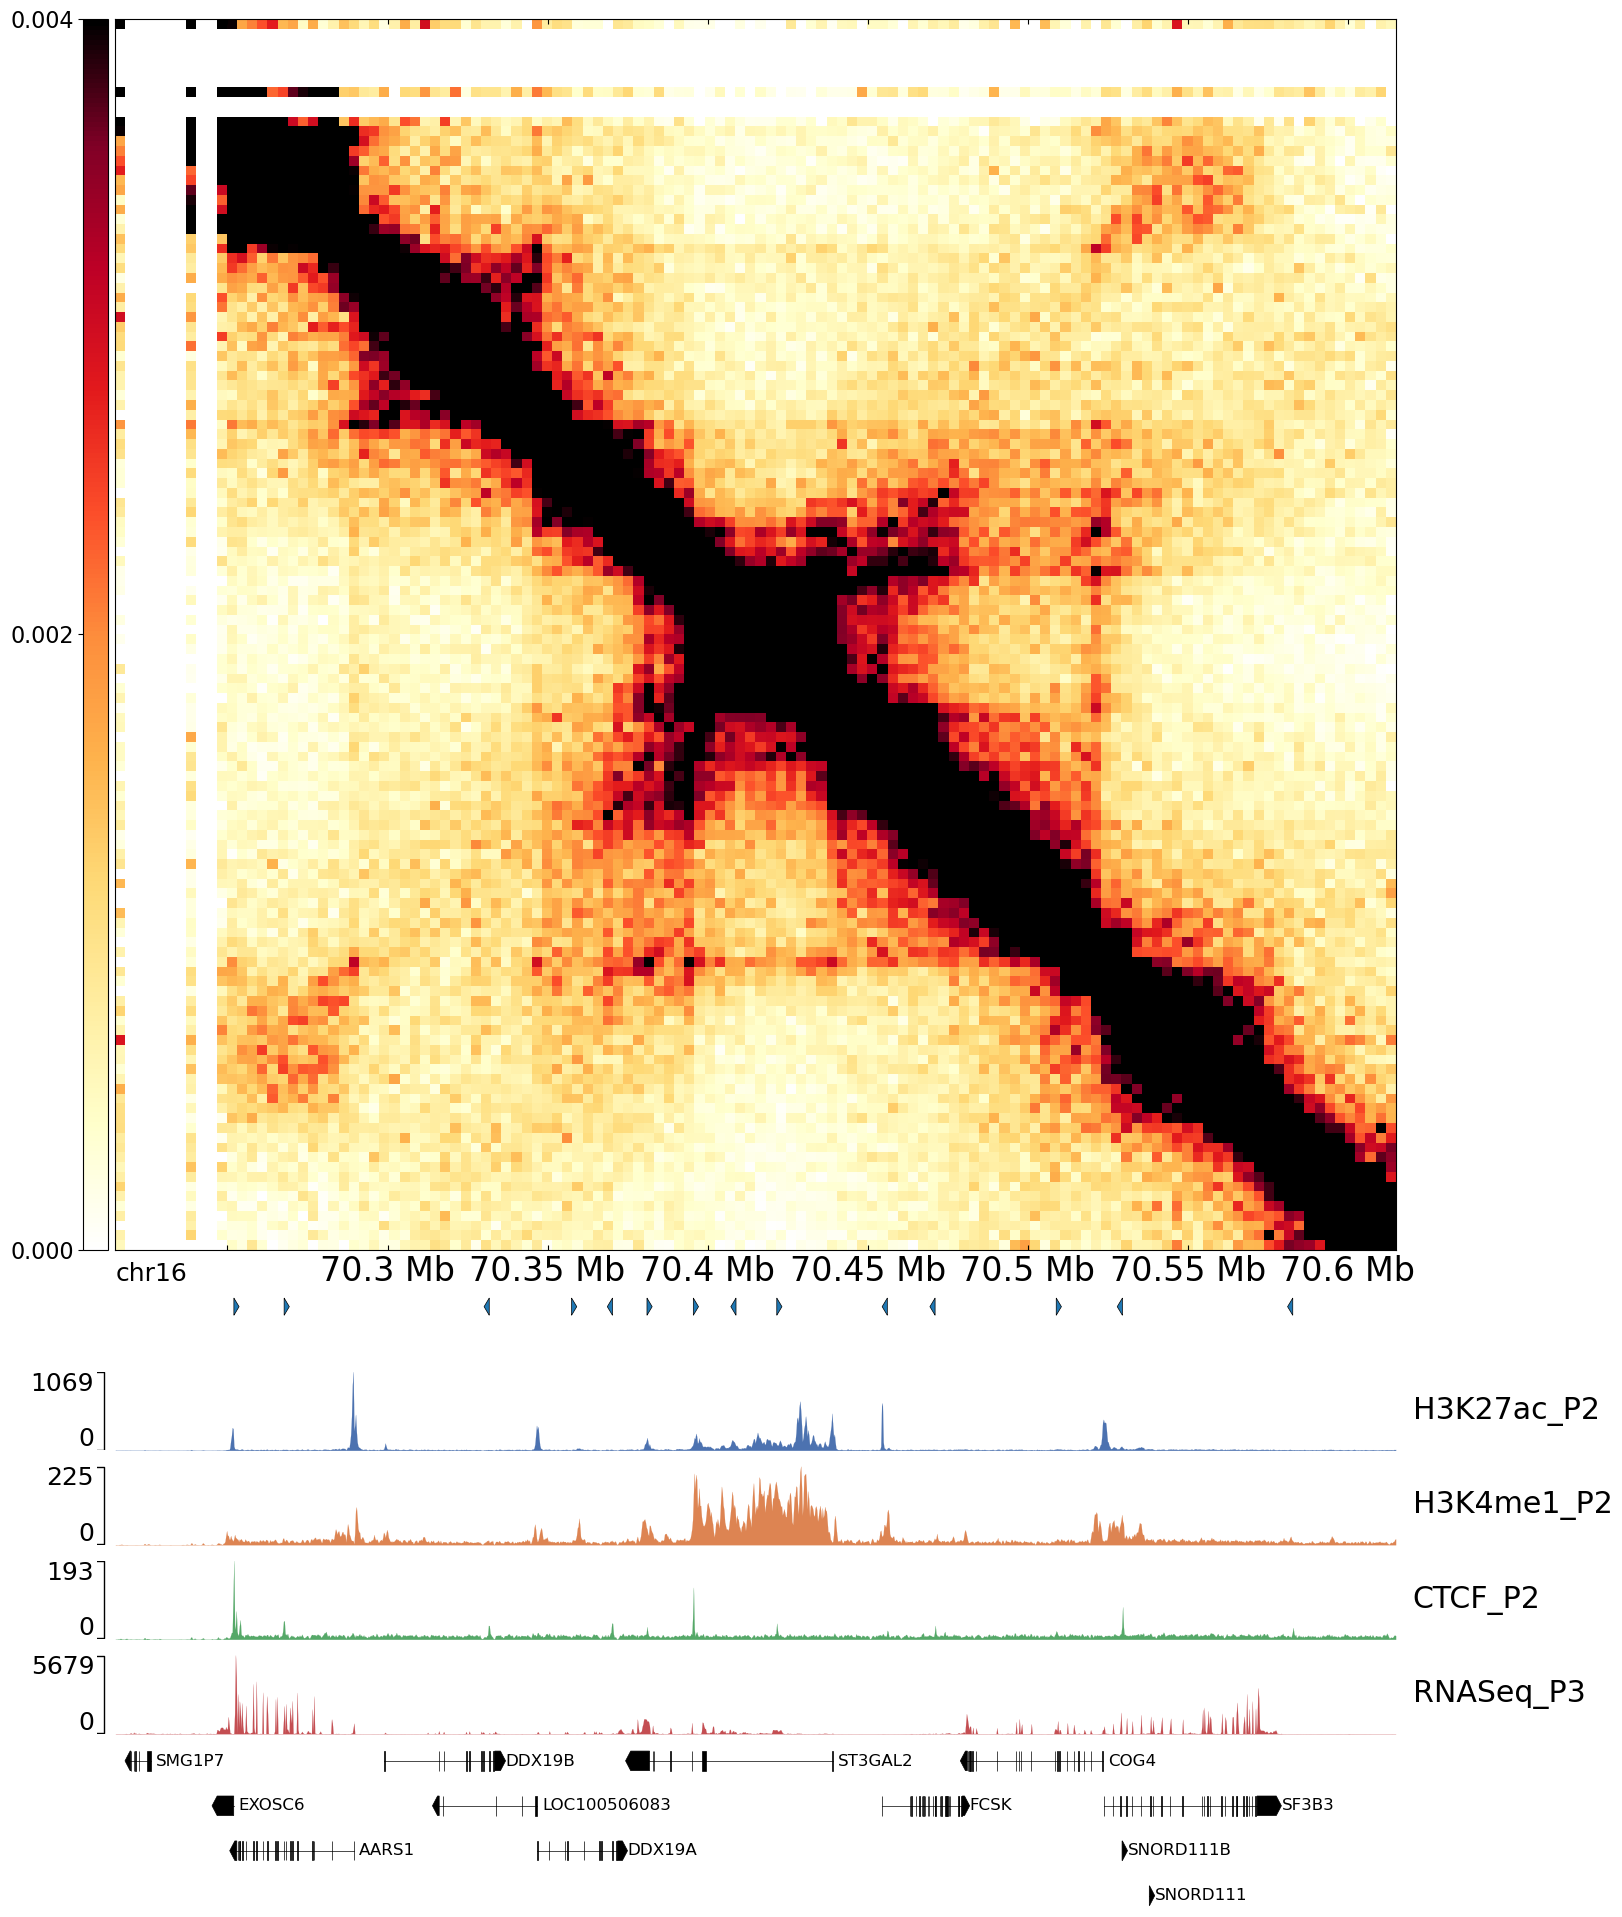

In [41]:
resolution=3200
figsf=[]

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                         "max_value":0.004,
                          "min_value":0.00,
                         "fontsize":18}


region_str = fountain_regions[1]
chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                             chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                            bedgraph_fname=None, plot_variants=False, plot_bed=True,
                             file_bottom =  uc_filenames[2], cmap_chip="deep", autoscale=True, plot_genes=True)
fig = frame.plot(region_str)
fig
    #fig.savefig(os.path.join(savedir, f"matchmaker_100kb_ranked_{match_id}.svg"))

chr1:32650195-32850195 2000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 28307/28307 [00:00<00:00, 34052.41it/s]
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


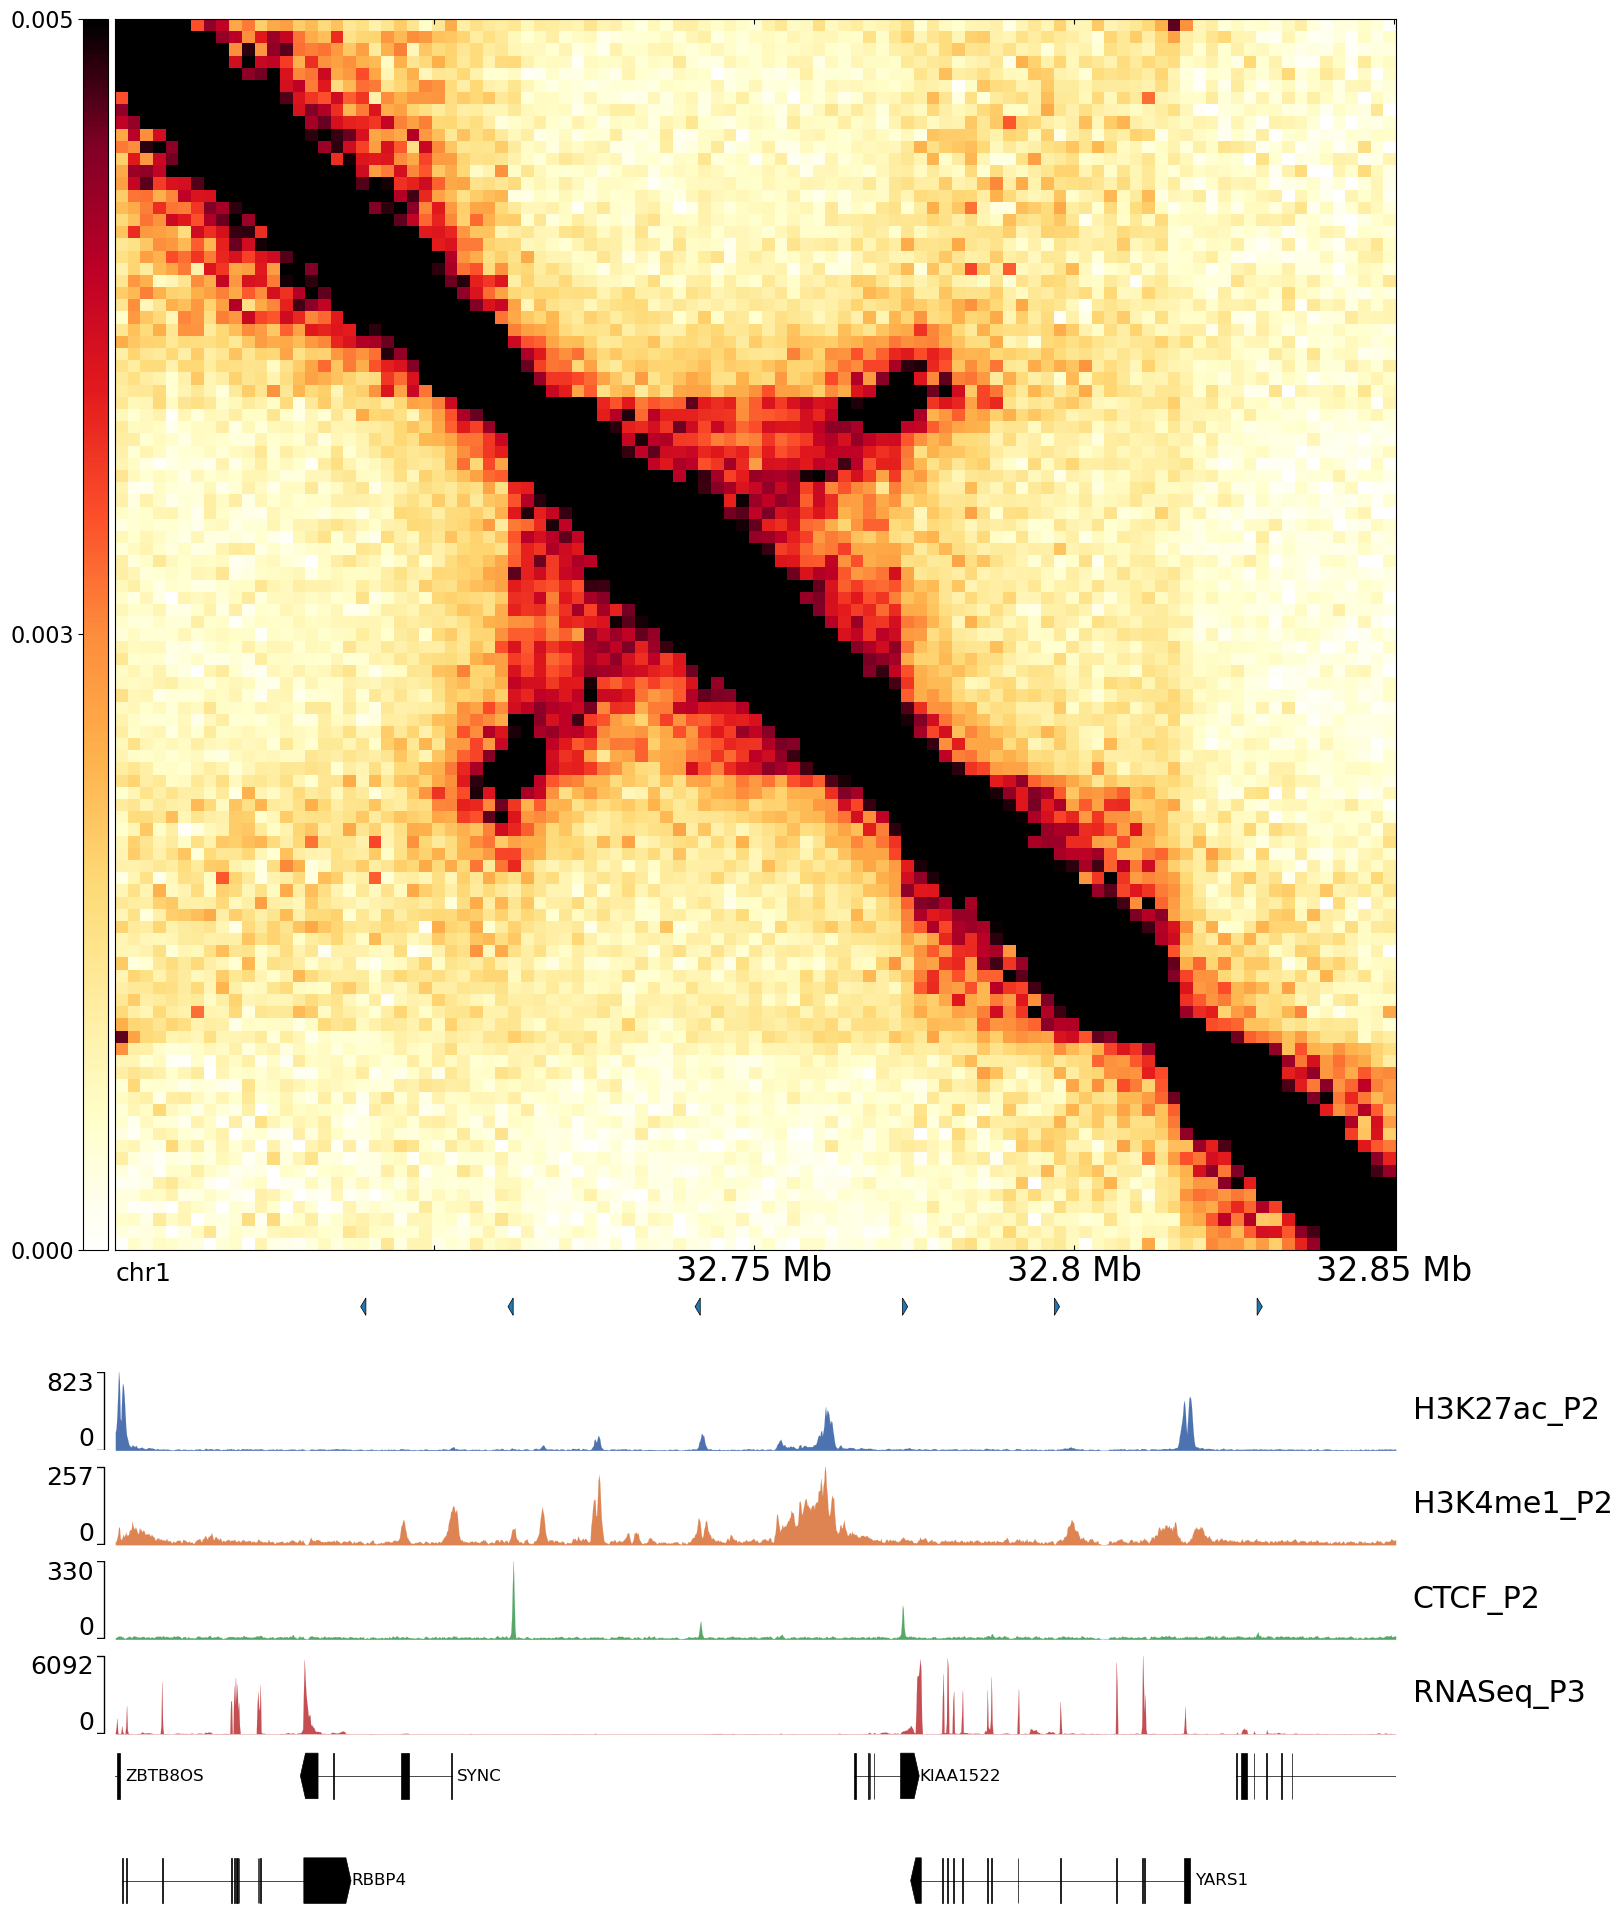

In [40]:
resolution=2000
figsf=[]

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                         "max_value":0.005,
                          "min_value":0.00,
                         "fontsize":18}


region_str = 'chr14:55056555-55166555'
region_str = 'chr18:11901677-12051677'
region_str = 'chr1:32650195-32850195'
chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                             chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                            bedgraph_fname=None, plot_variants=False, plot_bed=True,
                             file_bottom =  uc_filenames[2], cmap_chip="deep", autoscale=True, plot_genes=True)
fig = frame.plot(region_str)
fig
    #fig.savefig(os.path.join(savedir, f"matchmaker_100kb_ranked_{match_id}.svg"))

chr11:37,878,224-39,141,769 10000 /mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool


100%|██████████████████████████████████| 28307/28307 [00:00<00:00, 34077.91it/s]
[ERROR:frame.py:212 -                 plot()] Error occured when plot track:
	track name: NewBed.80
	track type:<class '__main__.NewBed'>
	Error: <class 'KeyError'> 'section_name'
	occurred in "/home/varshini/anaconda3/envs/mamba/envs/coolbox-mod/lib/python3.10/site-packages/coolbox/core/frame/frame.py", line 206
ERROR:coolbox.core.frame.frame:Error occured when plot track:
	track name: NewBed.80
	track type:<class '__main__.NewBed'>
	Error: <class 'KeyError'> 'section_name'
	occurred in "/home/varshini/anaconda3/envs/mamba/envs/coolbox-mod/lib/python3.10/site-packages/coolbox/core/frame/frame.py", line 206
[ERROR:frame.py:219 -                 plot()] 'section_name'
Traceback (most recent call last):
  File "/home/varshini/anaconda3/envs/mamba/envs/coolbox-mod/lib/python3.10/site-packages/coolbox/core/frame/frame.py", line 206, in plot
    track.plot(ax, copy(gr), gr2=copy(gr2))
  File "/tmp/ipykernel_239

You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


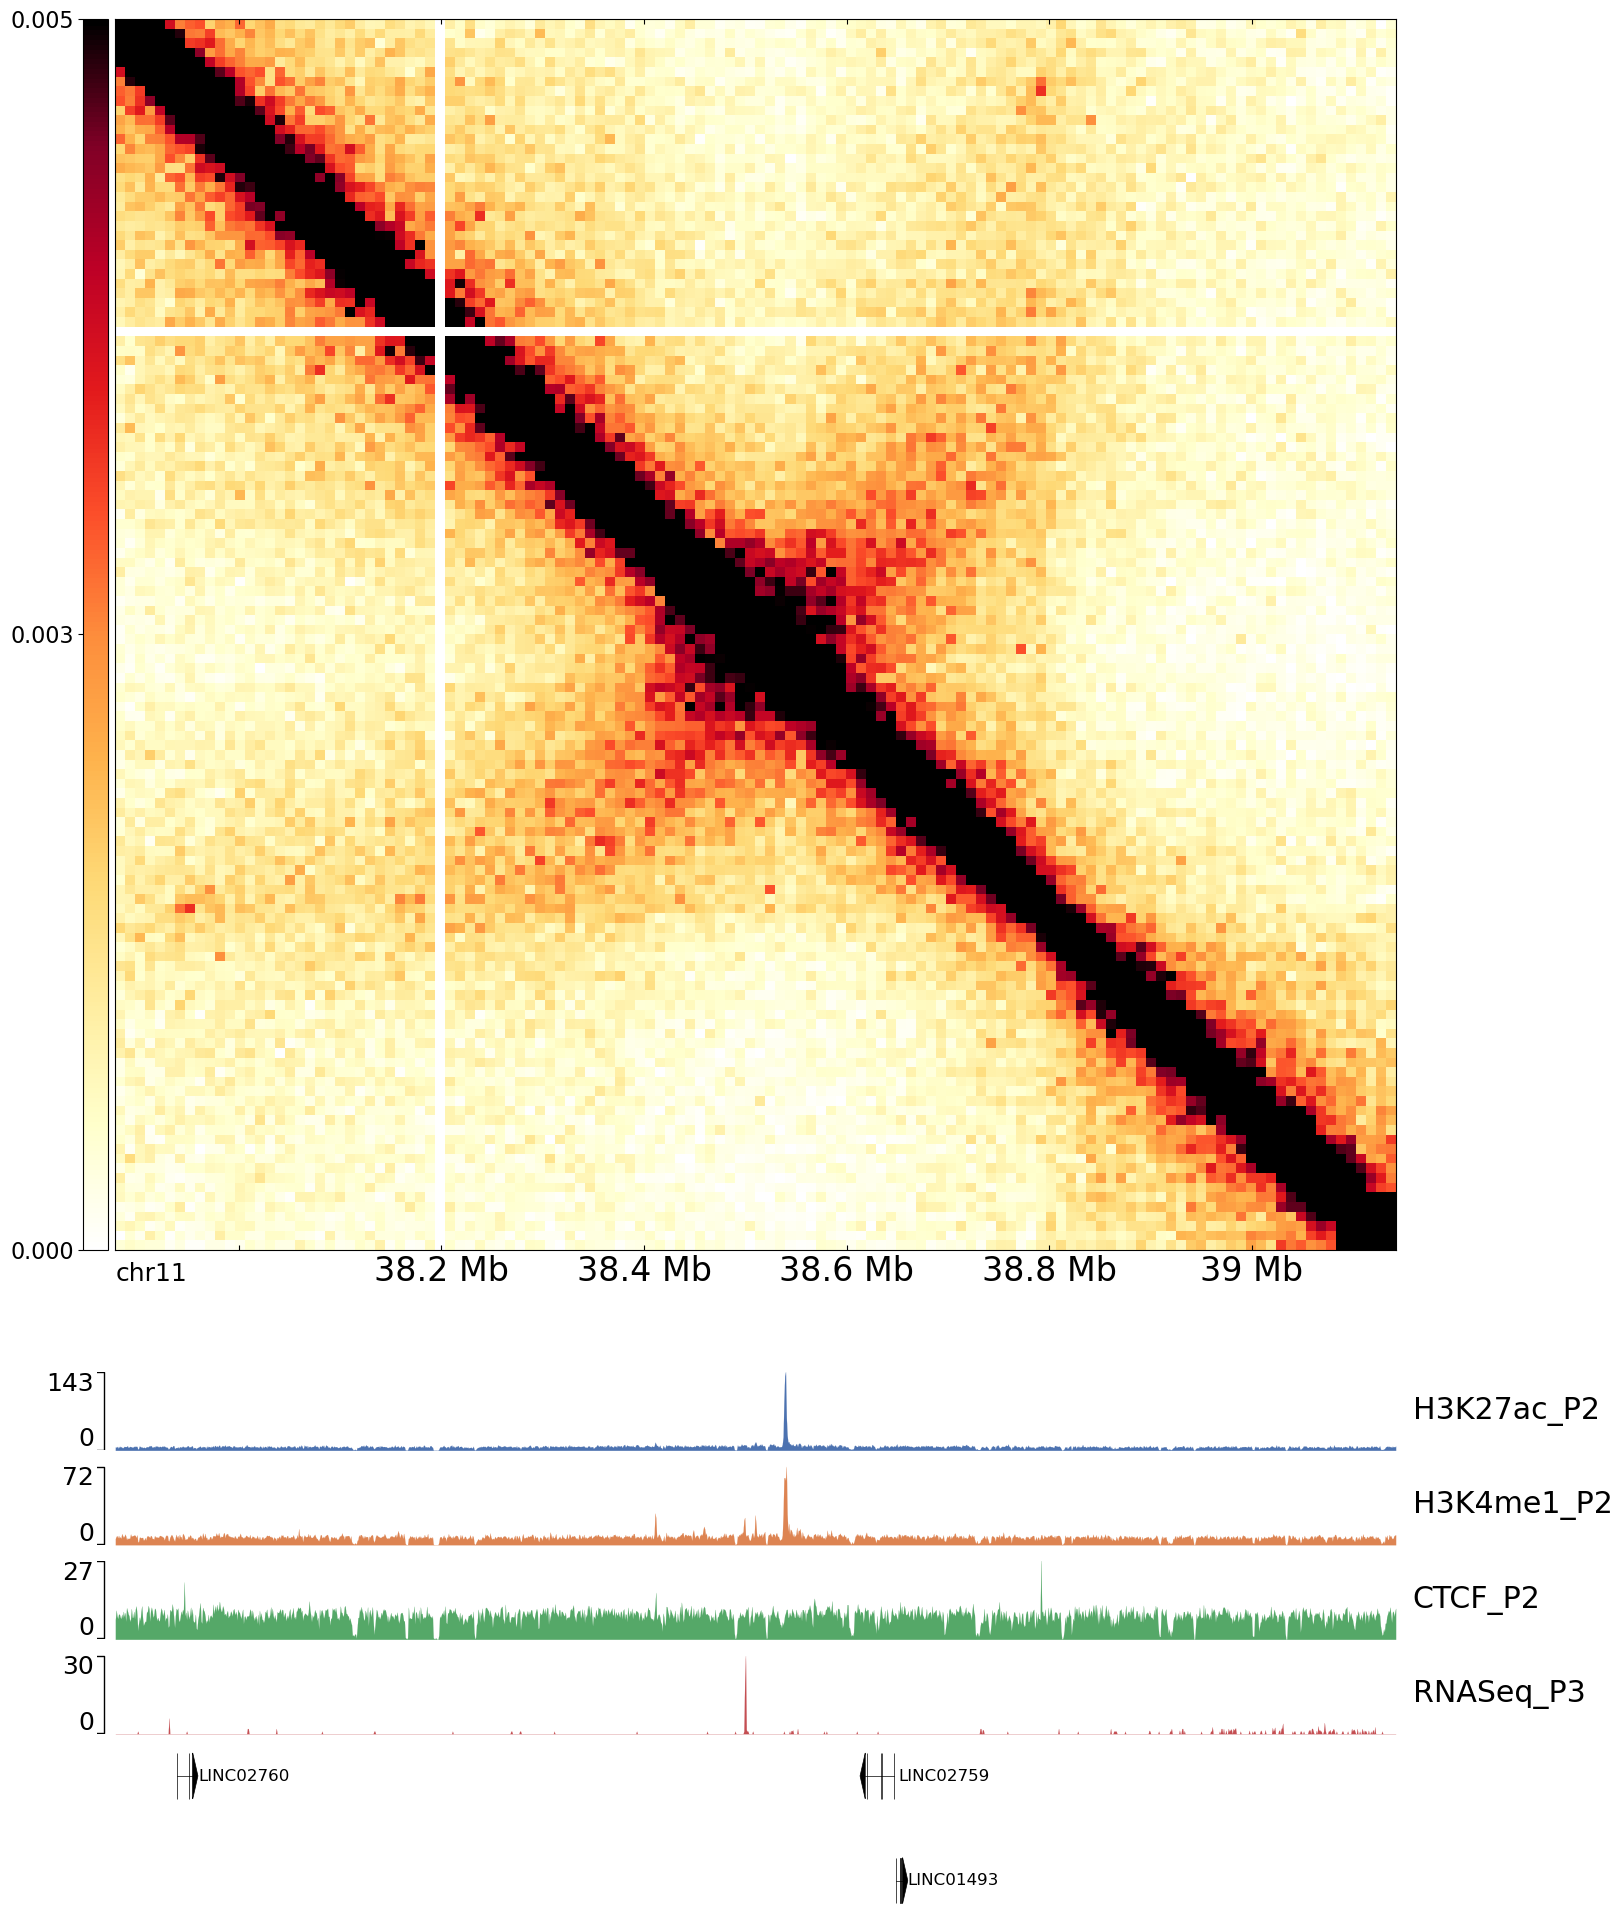

In [44]:
resolution=10000
figsf=[]

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                         "max_value":0.005,
                          "min_value":0.00,
                         "fontsize":18}


region_str = fountain_regions[2]
chip_list = get_chip_list(include=incl, phase=2, phase2=3)
frame = make_region_plot_mod(region_str, resolution, uc_filenames[2],
                             chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                            bedgraph_fname=None, plot_variants=False, plot_bed=True,
                             file_bottom =  uc_filenames[2], cmap_chip="deep", autoscale=True, plot_genes=True)
fig = frame.plot(region_str)
fig
    #fig.savefig(os.path.join(savedir, f"matchmaker_100kb_ranked_{match_id}.svg"))